In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
from matplotlib import pyplot as plt
import sys, os
sys.path.append("../../src/")


import scipy.stats as stats
from tqdm import tqdm
from baseline_network import BaselineNetwork

In [3]:
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams['font.size'] = 12
plt.rcParams['font.family'] = 'Arial'

In [4]:
net = BaselineNetwork(inh_type="co-tuned", E_to_E="on", E_to_I="on", I_to_I="off",
                      plasticity_E_to_E="off", plasticity_E_to_I="off", plasticity_I_to_E="off", plasticity_I_to_I="off",
                      norm=True, set_seed=True, seed=42, 
                      inh_scale=0.3)
net.run()

100%|██████████| 840/840 [00:55<00:00, 15.18it/s]


In [5]:
drift_mag, drift_rate, convergence = net.get_drift_metrics()

/Users/divyansh/Library/CloudStorage/GoogleDrive-divyanshg1207@gmail.com/My Drive/Course Stuff/PhD/Projects | PhD/sensory drift/drift_model_2026/scripts/full_network/../../src/baseline_network.py:759: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


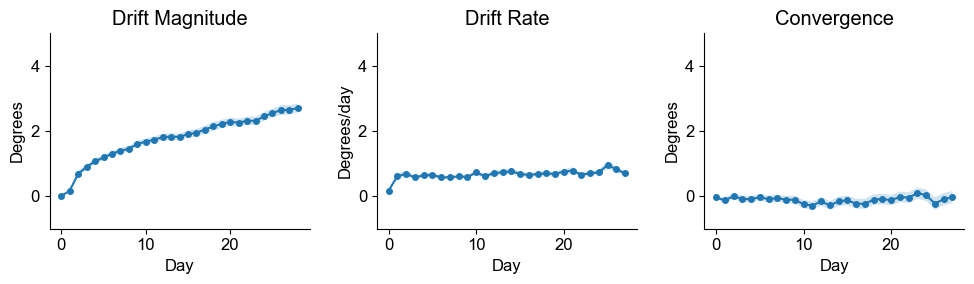

In [6]:
net.plot_drift_metrics(drift_mag, drift_rate, convergence)

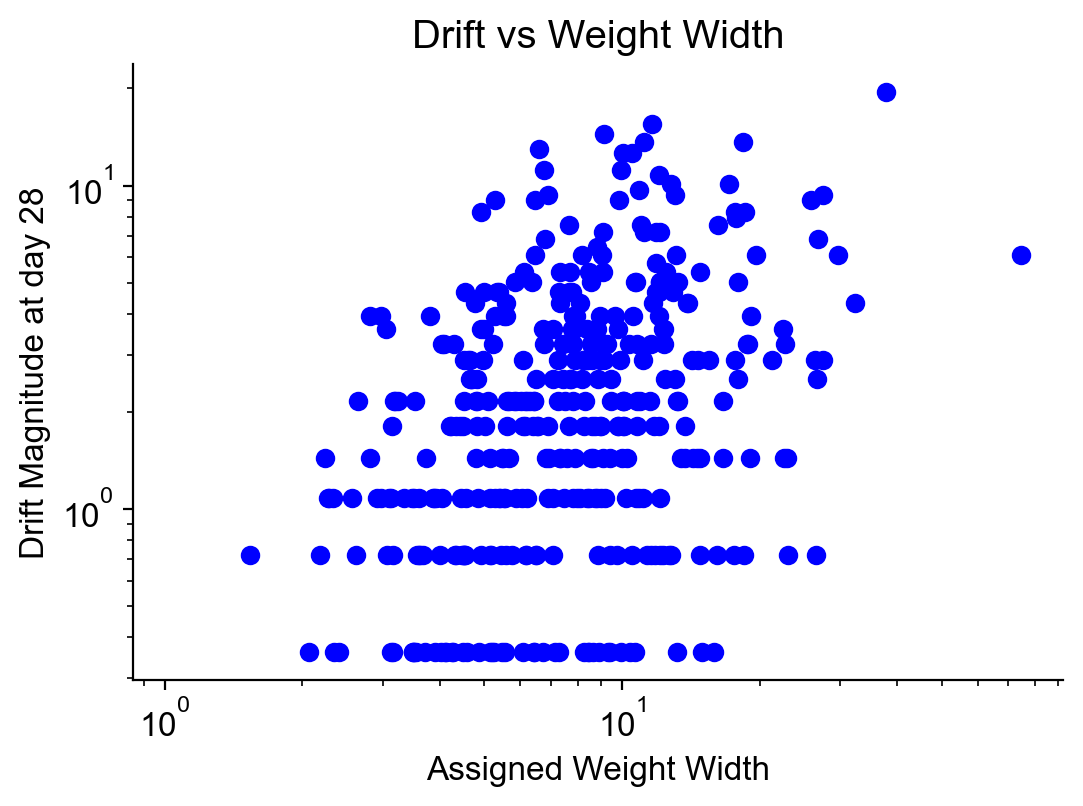

In [7]:
# Plot drift magnitude vs assigned weight width (vars_ef)

plt.figure(figsize=(6, 4), dpi=200)
plt.scatter(net.vars_ef, drift_mag[-1], color='blue')
plt.xlabel('Assigned Weight Width')
plt.ylabel('Drift Magnitude at day 28')
plt.title('Drift vs Weight Width')
plt.xscale('log')
plt.yscale('log')

plt.show()


/Users/divyansh/Library/CloudStorage/GoogleDrive-divyanshg1207@gmail.com/My Drive/Course Stuff/PhD/Projects | PhD/sensory drift/drift_model_2026/scripts/full_network/../../src/baseline_network.py:791: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


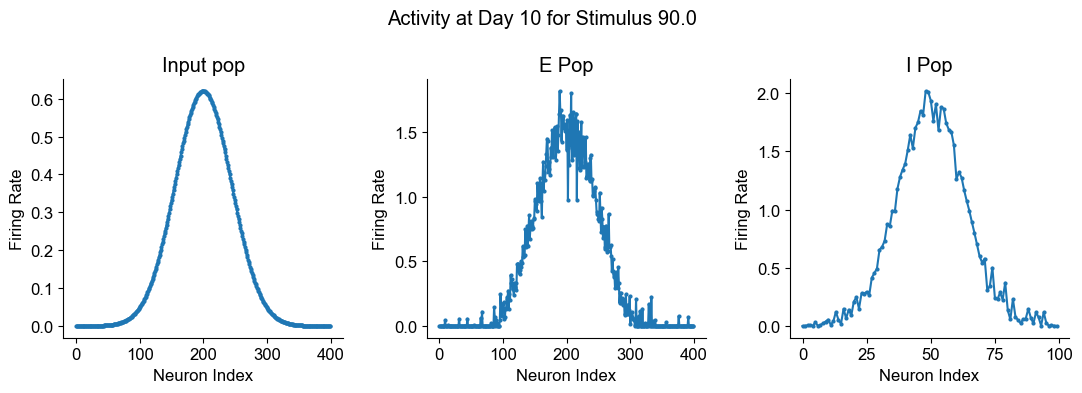

In [8]:
net.plot_activity_at_day(10, 90)

In [9]:
day = 10
tuning_curves = net.estimate_tuning_curves_at_day(day)


/Users/divyansh/Library/CloudStorage/GoogleDrive-divyanshg1207@gmail.com/My Drive/Course Stuff/PhD/Projects | PhD/sensory drift/drift_model_2026/scripts/full_network/../../src/baseline_network.py:659: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


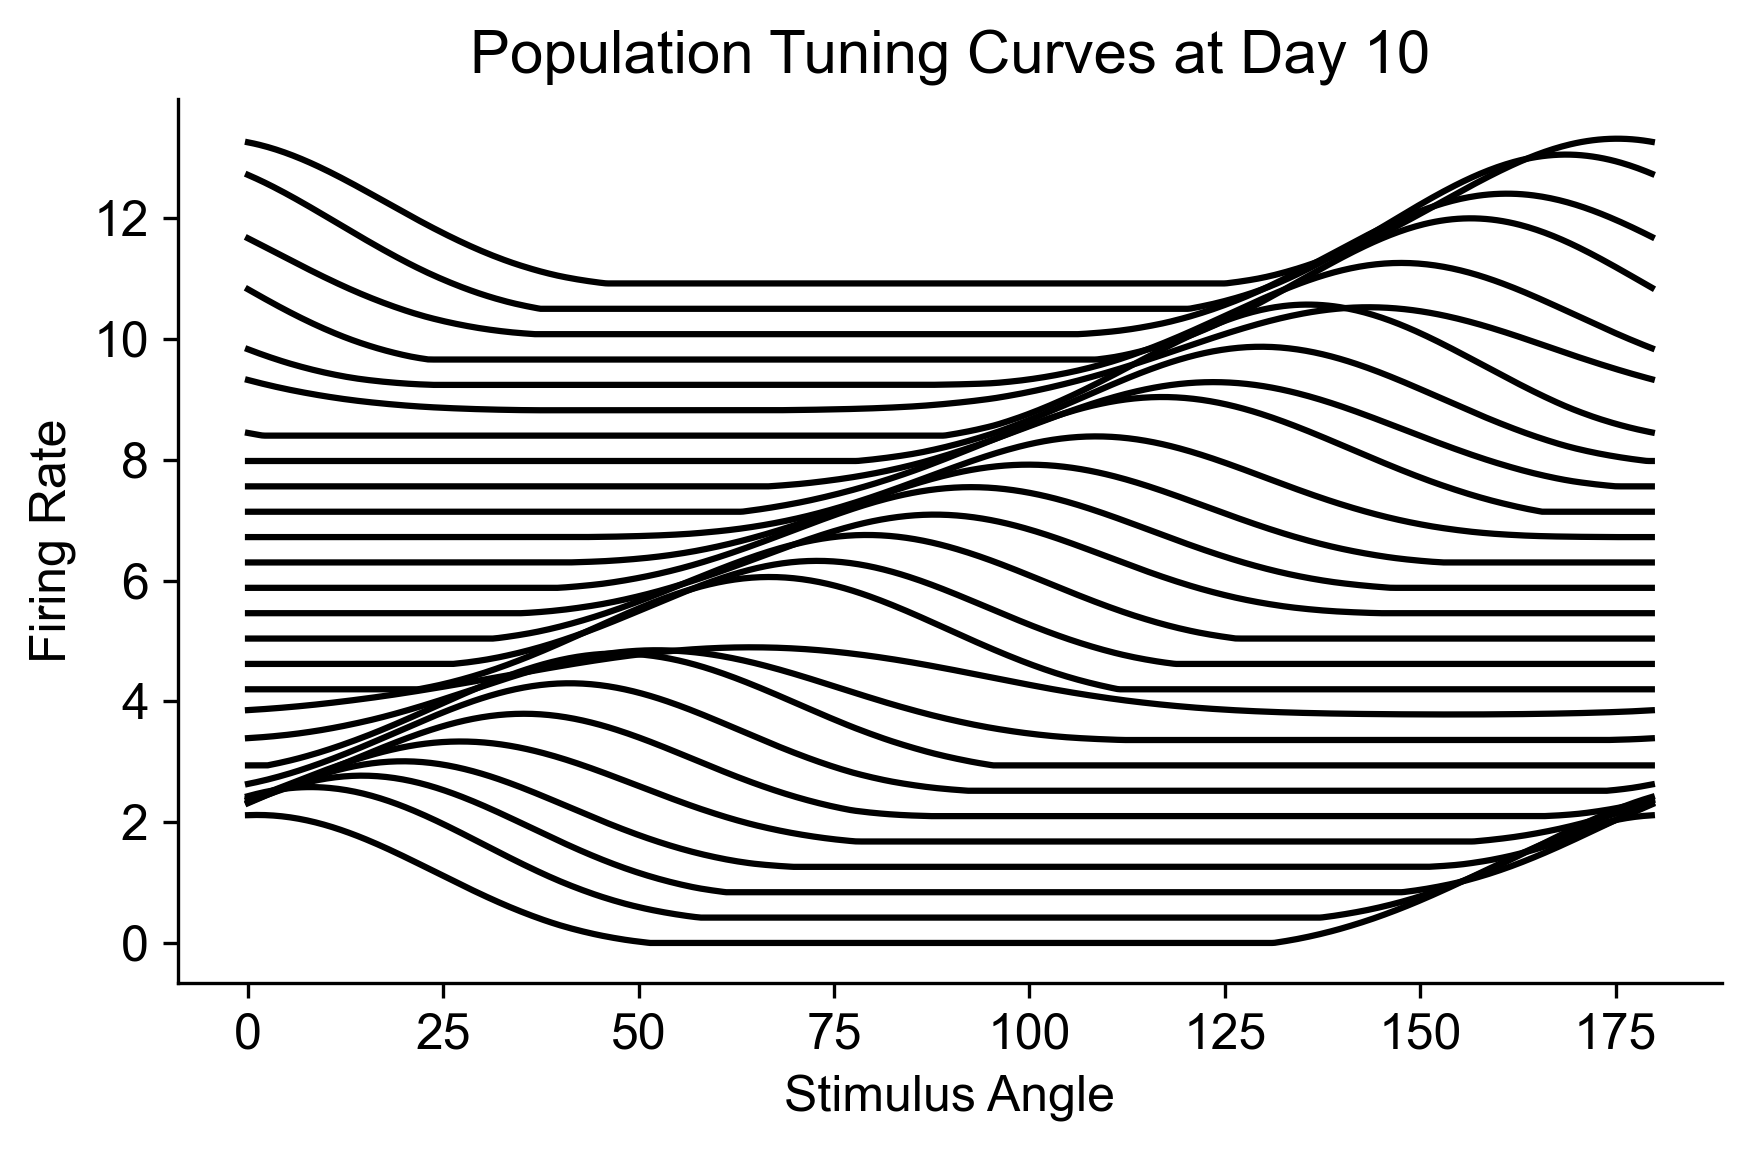

In [10]:
net.plot_population_tuning_curves(10)